# Introduction & Objective
We have a bank customer churn dataset, and we would like to analyze, investigate, and determine which variables affect whether a customer leaves the bank or not.

In [1]:
import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dotenv import load_dotenv

load_dotenv("supplementary/.env")  # reads MYSQL_* variables from a local .env file (gitignored, never committed)

connection = mysql.connector.connect(
    host=os.environ["MYSQL_HOST"],
    user=os.environ["MYSQL_USER"],
    password=os.environ["MYSQL_PASSWORD"],
    database=os.environ["MYSQL_DATABASE"]
)

os.makedirs("supplementary/figures", exist_ok=True)  # exported chart images live here (see README)


In [2]:
query = "SELECT * FROM `customer churn records`"

In [3]:
df = pd.read_sql(query, connection)

/var/folders/_w/jm3v4g8n57l_d36b6hnfy5yr0000gn/T/ipykernel_81175/1848774206.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [4]:
connection.close()

### Alternative: load from CSV

Skip the three SQL cells above and uncomment the cell below instead to read the same data straight from the CSV sitting in the project root.

In [5]:
# df = pd.read_csv("supplementary/Customer-Churn-Records.csv")

In [6]:
# Remove warnings that appear below
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) 

# Get a general sensing of the data that we will be working with
shape = df.shape
head = df.head()

print(f"there are {shape[0]} rows and {shape[1]} columns.")
print()
print(head)


there are 10000 rows and 18 columns.

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1              

# Data Quality Checks

In [7]:
# Confirm there are no missing values in any column.
is_null_checks = df.isnull().sum()
print(is_null_checks)
print()

# Confirm there are no duplicate customers.
dupe_checks = df['CustomerId'].duplicated().sum()
print(f"There are {dupe_checks} duplicates")


RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

There are 0 duplicates


In [8]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


# Field Descriptions

### Fields in the dataset
- RowNumber — corresponds to the record (row) number and has no effect on the output.
- CustomerId — contains random values and has no effect on customer leaving the bank.
- Surname — the surname of a customer has no impact on their decision to leave the bank.

1. CreditScore — can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.

2. Geography — a customer’s location can affect their decision to leave the bank.

3. Gender — it’s interesting to explore whether gender plays a role in a customer leaving the bank.

4. Age — this is certainly relevant, since older customers are less likely to leave their bank than younger ones.

5. Tenure — refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.

6. Balance — also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.

7. NumOfProducts — refers to the number of products that a customer has purchased through the bank.

8. HasCrCard — denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.

9. IsActiveMember — active customers are less likely to leave the bank.

10. EstimatedSalary — as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.

11. Exited — whether or not the customer left the bank.

12. Complain — customer has complaint or not.

- Satisfaction Score — Score provided by the customer for their complaint resolution.
- Card Type — type of card hold by the customer.
- Points Earned — the points earned by the customer for using credit card.



### The key indicator here is the column "Exited"
This is the column that indicates whether or not the customer has left the bank or not.

Numerical:
- CreditScore
- Age
- Tenure
- Balance
- EstimatedSalary
- Points Earned

Categorical:
- Geography
- Card Type
- NumOfProducts (only 1-4)
- Satisfaction Score (Ordinal)
- Gender
- HasCrCard
- IsActiveMember
- Complain
- Exited

# Univariate Analysis & Correlations

### Histrogram plot
Plotting a histogram of each numerical column to eyeball any field with large spikes or noteworthy variations.

array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Point Earned'}>]], dtype=object)

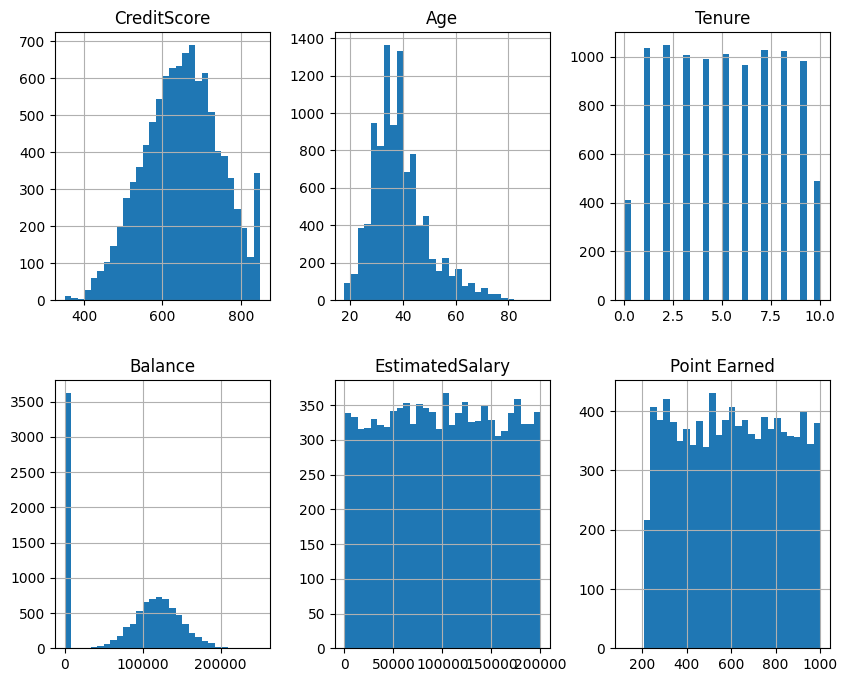

In [9]:
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "Point Earned"]
df[numeric_cols].hist(figsize=(10, 8), bins=30, layout=(2, 3))


Plotting a histogram for each column in numeric_cols, one field looks interesting where a large proportion of "0" balance accounts exist.

In [10]:
zero_balance_df = df[df['Balance'] == 0]
zero_balance_df.groupby(['Geography','IsActiveMember','Gender']).agg(
    balance = ('CustomerId', 'count')
)


balance
Geography IsActiveMember Gender         
France    0              Female      535
                         Male        623
          1              Female      574
                         Male        686
Spain     0              Female      270
                         Male        316
          1              Female      275
                         Male        338

We can see that there is an absence of Germany in this table, indicating that Germany has no customers with a "0" bank balance.

### Boxplot
Plotting a boxplot for each column in numeric_cols to spot outliers more precisely


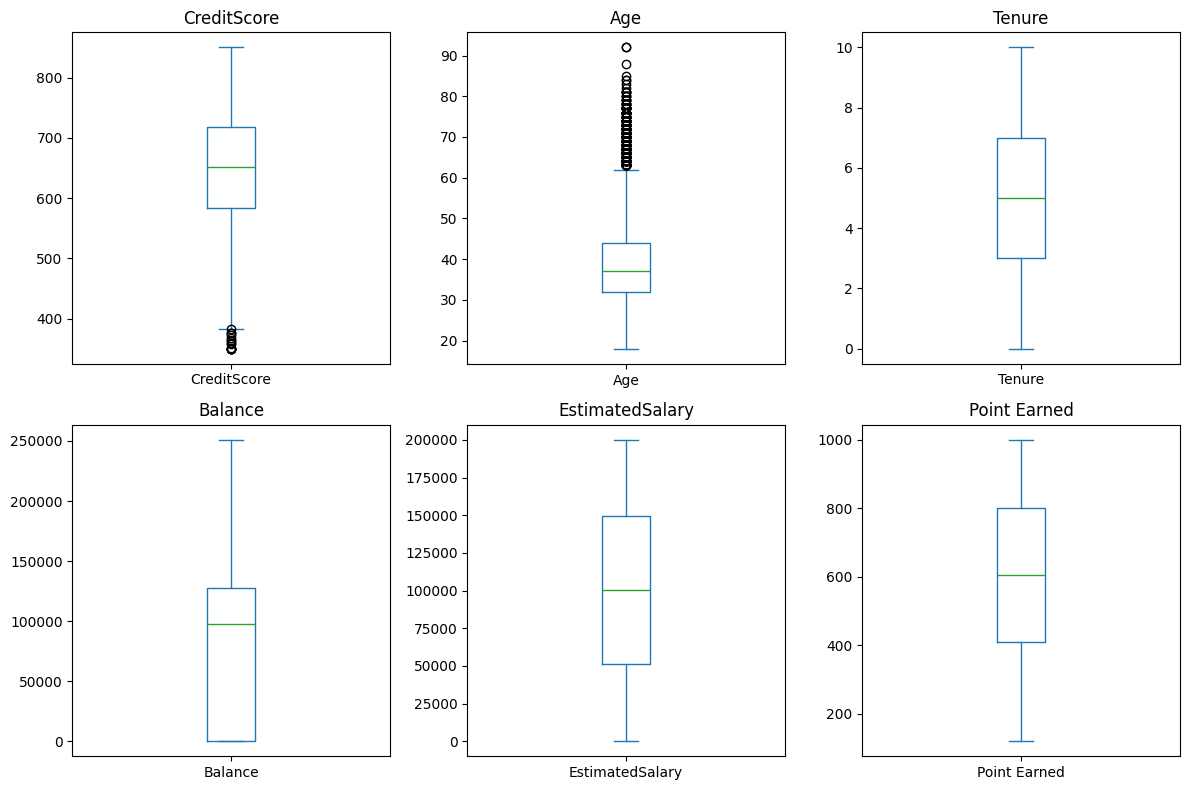

In [11]:
# Hint: loop over numeric_cols and call sns.boxplot(x=df[col]) for each,
# or use plt.subplots to lay them out in a grid

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    df[col].plot(kind='box', ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


1. CreditScore has a small cluster of low-end outlier circles below 400 below the Q1 and Q3 of 580-718. It is worth checking these low-end outliers to see if an extremely low credit score could lead to a higher churn rate

2. Age has many high-end outlier circles above 62 above the Q1 and Q3 of 32-44.

3. balance's Q1 sits at 0, which indicates many 0 account balances (consistent with the historgram above)

### Heatmap
Plotting a heatmap to find strong pairwise correlations between fields

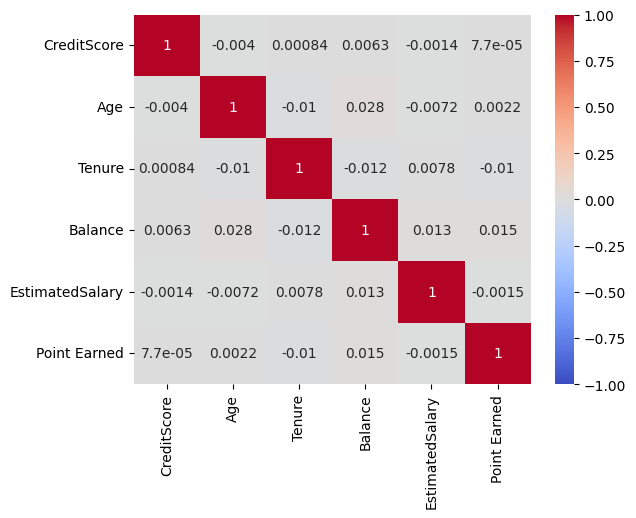

In [12]:
corr = df[numeric_cols].corr()
ax = sns.heatmap(corr, annot=True, cmap="coolwarm",vmin=-1, vmax=1, center=0)
ax.figure.savefig("supplementary/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")


Not much to infer from here - simply that there is no serious multicollinearity between the continuous variables. Each variable contributes independent information from one another.

The largest correlation is Age and Balance with 0.028 correlation. Makes sense as an older person would likely have a higher balance in their account.

In [13]:
# I will remove all unnecessary columns
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Customer Base Overview

In [14]:
Gender_summary_table = df.groupby('Gender').agg(
    Gender_Count = ('Gender','count'),
    Total_Exits = ('Exited','sum'),
    Churn_Rate = ('Exited',lambda x: x.mean() * 100),
    Avg_age = ('Age', 'mean'),
    Avg_NumOfProducts = ('NumOfProducts', 'mean'),
    Avg_tenure = ('Tenure','mean'),
    Avg_Balance = ('Balance', 'mean'),
    Percent_HasCrCard = ('HasCrCard',lambda x: x.mean() *100),
    Percent_IsActiveMember = ('IsActiveMember',lambda x: x.mean() *100),
    Avg_EstSalary = ('EstimatedSalary','mean')
).reset_index()

print(Gender_summary_table)

Churn_Rate = df['Exited'].sum()/df['Exited'].count()

print()
print(f" The baseline general Churn Rate is {Churn_Rate*100:.2f}%")

   Gender  Gender_Count  Total_Exits  Churn_Rate    Avg_age  \
0  Female          4543         1139   25.071539  39.238389   
1    Male          5457          899   16.474253  38.658237   

   Avg_NumOfProducts  Avg_tenure   Avg_Balance  Percent_HasCrCard  \
0           1.544134    4.966102  75659.369139          70.261941   
1           1.518600    5.051677  77173.974506          70.789811   

   Percent_IsActiveMember  Avg_EstSalary  
0               50.275149  100601.541382  
1               52.538025   99664.576931  

 The baseline general Churn Rate is 20.38%


There are certainly some factors which affect the churn rate more than others. From the table above, we can already clearly see that there is a higher population of male customers than female customers, but there is a higher proportion of female customers who are leaving the bank. 

This is interesting, and perhaps female customers fit a certain profile (Less active of a member, purchased a higher number of products, higher estimated salary etc). Let's investigate further!

# Initial Regression

In [15]:
# I want to run a full logistics regression to more clearly ascertain which fields have a greater impact on "Exited" 
# before i go in depth into any one particular field
import statsmodels.api as sm

X = pd.get_dummies(
    df.drop(columns=["Exited"]), # Exclude "Exited" from the predictors
    columns=["Geography", "Gender", "Card Type", "Satisfaction Score", "HasCrCard", "IsActiveMember","Complain"], # Convert categorical data columns into dummy variables
    drop_first=True, # Removes 1 category to prevent perfect multicollinearity
    dtype=float
)

X = sm.add_constant(X) # Adds a "Constant" column to the X fields

y = df["Exited"]

model = sm.Logit(y, X).fit()

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 1000)

print(model.summary())
with open("supplementary/Initial Regression.txt", "w") as f:
  f.write(model.summary().as_text())

Optimization terminated successfully.
         Current function value: 0.007782
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9979
Method:                           MLE   Df Model:                           20
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.9846
Time:                        02:28:13   Log-Likelihood:                -77.818
converged:                       True   LL-Null:                       -5056.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -9.0958      2.721     -3.343      0.001     -14.429      -3.76

In [16]:
odds_ratios = np.exp(model.params)
pd.set_option('display.float_format', '{:.6f}'.format)

# Logistic regression coefficients are expressed in log-odds.
# Exponentiating them converts them into odds ratios

print(odds_ratios)

const                        0.000112
CreditScore                  1.000621
Age                          1.103407
Tenure                       0.937959
Balance                      1.000002
NumOfProducts                0.757124
EstimatedSalary              1.000002
Point Earned                 0.997269
Geography_Germany            0.495527
Geography_Spain              1.248303
Gender_Male                  0.737072
Card Type_GOLD               0.514826
Card Type_PLATINUM           0.491535
Card Type_SILVER             1.322092
Satisfaction Score_2         1.769764
Satisfaction Score_3         0.140275
Satisfaction Score_4         1.827391
Satisfaction Score_5         0.225966
HasCrCard_1                  0.967247
IsActiveMember_1             0.179051
Complain_1             3435075.747633
dtype: float64


From the logit regression results, we can see a few variables which have a strong(er) relationship with "Exited", and some with minimal/no correlation at all.

**Odds Ratio (OR)**

`exp(coefficient)` — the multiplicative change in the odds of `Exited = 1` for a one-unit increase in that predictor (continuous variables), or relative to the reference category (dummy variables), holding every other variable constant.
- OR > 1 → odds of churning go up
- OR < 1 → odds of churning go down
- OR = 1 → no effect
- Example: OR = 1.10 means +10% higher odds per unit increase; OR = 0.75 means 25% lower odds.

**P-value**

The probability of seeing a coefficient this extreme (or more) if the variable actually had no real relationship with churn (the "null hypothesis"). Convention: p < 0.05 → treat as statistically significant.

Important distinction: **statistical significance ≠ practical significance**. A tiny, meaningless effect (CreditScore) can still get a low p-value with enough data, and a real effect can fail to reach significance if something else in the model is broken.

### Per-factor breakdown
| Factor | OR | p-value | Significant? (p<.05) | Meaningful? |
|---|---|---|---|---|
| const | 0.000112 | 0.001 | — | Not a predictor — it's the baseline log-odds when every other variable is at its reference level. |
| CreditScore | 1.0006 | 0.828 | No | No — not significant, and even if it were, +1 point only moves odds by 0.06%. |
| **Age** | **1.1034** | **<0.001** | **Yes** | **Yes — real driver.** Each extra year of age raises churn odds ~10.3%. |
| Tenure | 0.9380 | 0.505 | No | No — no meaningful effect in this model (confirmed again in the revised model, p=0.063). |
| Balance | 1.000002 | 0.734 | No | No — not significant and the effect size is essentially zero regardless. |
| NumOfProducts | 0.7571 | 0.419 | No | **Misleading, not "no effect."** The bivariate section shows 3–4 products correlating with much higher churn; this coefficient even has the wrong sign. Quasi-separation damage — don't trust this row. |
| EstimatedSalary | 1.000002 | 0.723 | No | No — negligible effect size either way. |
| Point Earned | 0.9973 | 0.049 | Borderline | Statistically significant by a hair, but a full 100-point swing only moves odds ~2.4%. Not practically meaningful. |
| Geography_Germany | 0.4955 | 0.334 | No | **Misleading.** The Geography section shows Germany churning at ~2x France/Spain. Another casualty of the separation problem — the revised model recovers this (OR 2.58, p<0.001). |
| Geography_Spain | 1.2483 | 0.777 | No | No — and this holds up later too (Spain genuinely isn't different from France). |
| Gender_Male | 0.7371 | 0.579 | No | **Misleading.** The Customer Base Overview table shows a real gender gap (16.5% vs 25.1% churn); the revised model confirms it (OR 0.592, p<0.001). Washed out here by the separation issue. |
| Card Type_GOLD | 0.5148 | 0.408 | No | No effect — holds up later (Card Type never becomes significant). |
| Card Type_PLATINUM | 0.4915 | 0.349 | No | No effect — same as above. |
| Card Type_SILVER | 1.3221 | 0.730 | No | No effect — same as above. |
| Satisfaction Score_2 | 1.7698 | 0.606 | No | No effect. |
| Satisfaction Score_3 | 0.1403 | 0.052 | Borderline | Extreme OR but no logical pattern across the other levels (2, 4, 5 aren't significant and don't trend consistently) — reads as model noise, not signal. Confirmed as noise in the revised model too. |
| Satisfaction Score_4 | 1.8274 | 0.584 | No | No effect. |
| Satisfaction Score_5 | 0.2260 | 0.156 | No | No effect. |
| HasCrCard_1 | 0.9672 | 0.956 | No | No — about as close to "zero effect" as this model produces. |
| **IsActiveMember_1** | **0.1791** | **0.006** | **Yes** | **Yes — real driver**, and one of the few that survives the separation problem intact. Active members have ~82% lower odds of exiting (this shrinks to ~67% lower in the cleaner revised model, but direction and significance hold up both times). |
| Complain_1 | 3,435,075.7 | <0.001 | "Yes" (but meaningless) | **This is the bug, not a finding.** p<0.001 just confirms `Complain` almost perfectly predicts `Exited` (2,034/2,044 complainers left) — that's quasi-separation, not a real 3.4-million-fold effect. Don't report this number anywhere. |

**Bottom line:** out of 20 real predictors, **Age** and **IsActiveMember** can be trusted. Everything else is either null (CreditScore, Balance, EstimatedSalary, HasCrCard, Card Type, Tenure) or a false negative caused by `Complain` distorting the model (NumOfProducts, Geography_Germany, Gender_Male).

This regression can't be trusted as it stands. `Complain` comes out with an odds ratio over 3 million, and statsmodels itself flags "possibly complete quasi-separation." That happens because almost every customer who complained also left (2,034 of 2,044), so `Complain` is basically standing in for the outcome itself rather than acting as an independent predictor. Including it in the regression distorts the standard errors for every other variable in the model. See the Revised Regression section below for a version with `Complain` removed that can actually be trusted.

### Investigating 'Complain' Variable

In [17]:
pd.crosstab(df["Complain"],df["Exited"])

Exited,0,1
Complain,,
0,7952,4
1,10,2034


From the crosstab, we can see that almost all customers who lodged a complaint against the bank ended up leaving. 
We cannot simply assume causality and say that customers left the bank because they lodged a complain.

Since a complaint almost always comes hand in hand with the customer leaving, we have to look at the other variables to find out why exactly the customers are complaining which leads to them leaving

# Revised Regression

The initial regression above triggered a *"possibly complete quasi-separation"* warning from statsmodels, and `Complain` came out with coef 15.05 / odds ratio ~3.4 million. The crosstab in the next section shows why: 2,034 of 2,044 complainers exited, and only 4 of 7,956 non-complainers exited (99.86% agreement with `Exited`). `Complain` is functioning as a near-duplicate of the outcome rather than an independent predictor, and including it inflates the standard errors on *every* other coefficient — that's what quasi-separation does. It is also why the original Pseudo R² of 0.9846 is unrealistically high, and why several variables I'd flagged for further investigation (Tenure, NumOfProducts, Geography, Card Type) came out statistically insignificant (p > 0.3) in that first model despite showing clear patterns in the bivariate breakdowns further down this notebook.

Changes made for this revised model:
1. **Dropped `Complain`** — outcome-adjacent leakage, not a driver.
2. **Checked `Satisfaction Score` for the same issue first.** The field is described as "score for their complaint resolution," but the mean/distribution is identical for complainers (mean 3.00) and non-complainers (mean 3.02), so it isn't gated by complaint status in this data. Kept it in and still treated as categorical.
3. **Grouped `NumOfProducts` into 1 / 2 / 3+** instead of 1/2/3/4. All 60 customers with 4 products exited, so that category is a perfect predictor on its own and creates a *second* quasi-separation problem if left as its own dummy. 3 and 4 products already showed a similarly extreme exit rate (82.7% and 100%), so merging them is a small loss of granularity in exchange for a model that actually converges.

Everything else (Geography, Gender, Card Type, HasCrCard, IsActiveMember as dummies; CreditScore, Age, Tenure, Balance, EstimatedSalary, Point Earned as continuous) is unchanged from the original specification.

In [18]:
# Revised regression: excludes Complain (outcome leakage / source of the
# quasi-separation warning above), and groups NumOfProducts into 1 / 2 / 3+
# since the 4-product category is a perfect predictor on its own (60/60 exited)

df['NumOfProducts_grp'] = df['NumOfProducts'].apply(lambda n: '3+' if n >= 3 else str(n))

categorical_cols = ["Geography", "Gender", "Card Type", "Satisfaction Score",
                     "HasCrCard", "IsActiveMember", "NumOfProducts_grp"]
exclude_cols = ["Exited", "Complain", "NumOfProducts"]

# Defensively drop any other non-numeric column (e.g. Credit Score Band, age_bin,
# balance_bin) that may already exist in df if other cells further down were run
# out of order earlier in this kernel session — these are re-derived elsewhere in
# the notebook and aren't part of this model's feature set.
other_non_numeric = [c for c in df.columns
                      if c not in categorical_cols + exclude_cols
                      and df[c].dtype.name in ("object", "category")]

X_rev = pd.get_dummies(
    df.drop(columns=exclude_cols + other_non_numeric),
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

X_rev = sm.add_constant(X_rev)
y = df["Exited"]

revised_model = sm.Logit(y, X_rev).fit()
print(revised_model.summary())

Optimization terminated successfully.
         Current function value: 0.372078
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9979
Method:                           MLE   Df Model:                           20
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.2641
Time:                        02:28:13   Log-Likelihood:                -3720.8
converged:                       True   LL-Null:                       -5056.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.7515      0.276     -9.977      0.000      -3.292      -2.211

In [19]:
odds_ratios_rev = np.exp(revised_model.params)
conf_rev = np.exp(revised_model.conf_int())
conf_rev.columns = ['OR 2.5%', 'OR 97.5%']

revised_results = pd.concat([
    odds_ratios_rev.rename('Odds Ratio'),
    revised_model.pvalues.rename('P>|z|'),
    conf_rev
], axis=1)

pd.set_option('display.float_format', '{:.4f}'.format)
print(revised_results)

                      Odds Ratio  P>|z|  OR 2.5%  OR 97.5%
const                     0.0638 0.0000   0.0372    0.1096
CreditScore               0.9993 0.0225   0.9987    0.9999
Age                       1.0743 0.0000   1.0684    1.0801
Tenure                    0.9814 0.0631   0.9622    1.0010
Balance                   1.0000 0.2518   1.0000    1.0000
EstimatedSalary           1.0000 0.3654   1.0000    1.0000
Point Earned              0.9999 0.2827   0.9996    1.0001
Geography_Germany         2.5779 0.0000   2.2348    2.9736
Geography_Spain           1.0502 0.5194   0.9047    1.2191
Gender_Male               0.5922 0.0000   0.5275    0.6648
Card Type_GOLD            0.8985 0.1979   0.7635    1.0575
Card Type_PLATINUM        0.9606 0.6258   0.8172    1.1291
Card Type_SILVER          1.0174 0.8334   0.8659    1.1955
Satisfaction Score_2      1.1988 0.0507   0.9995    1.4378
Satisfaction Score_3      1.0078 0.9346   0.8378    1.2122
Satisfaction Score_4      1.0462 0.6295   0.8707    1.25

## Revised model results

The revised model converges more cleanly with no separation warning. Pseudo R² drops from 0.9846 to **0.264**, which is a much more realistic number for a churn model and good confirmation that the original score was an artifact of the `Complain` leakage rather than genuine predictive power.

### Factors that actually affect churn (p < 0.05)

| Factor | Odds Ratio | p-value | What it means |
|---|---|---|---|
| NumOfProducts: 3+ (vs. 1) | **16.47** | <0.001 | Customers with 3 or more products have ~16.5x the odds of exiting compared to customers with just 1. By far the strongest driver in the model - confirms the pattern in the NumOfProducts section below, now with a stable estimate instead of a coefficient the original model got the *sign* wrong on. |
| NumOfProducts: 2 (vs. 1) | 0.213 | <0.001 | Customers with exactly 2 products have ~79% lower odds of exiting than customers with 1 to 2 products is the safest tier, not the middle of a straight-line trend. |
| IsActiveMember (active vs. inactive) | 0.332 | <0.001 | Active members have ~67% lower odds of exiting than inactive members. One of the strongest, most actionable levers - this came through partially in the original model (p=0.006) but is much cleaner here. |
| Geography: Germany (vs. France) | 2.578 | <0.001 | Germany customers have ~2.6x the odds of exiting versus France, holding everything else constant — confirms the raw 32.4% vs 16.2% churn-rate gap found below isn't just explained away by Germany's higher average balance. |
| Age | 1.074 per year | <0.001 | Each additional year raises the odds of exiting by ~7.4%. Compounds fast - a 50-year-old has roughly 4x the odds of a 30-year-old, consistent with the >42 age-group pattern found below. |
| Gender: Male (vs. Female) | 0.592 | <0.001 | Male customers have ~41% lower odds of exiting than female customers. The original notebook's Customer Base Overview claimed this pattern but never displayed a table to back it up (worth fixing) - this regression result confirms the direction. |
| CreditScore | 0.9993 per point | 0.023 | Statistically significant, but the effect size is close to nothing in practice - a full 100-point swing only moves the odds by about 7% (in the expected direction: higher score, lower churn odds). I'd leave this out of the dashboard's driver list; it's real but not actionable. |

### Not significant factors
- **Geography: Spain** (vs. France) - p = 0.52.
- **Card Type** (Gold / Platinum / Silver, vs. Diamond) - p = 0.20 to 0.83 across all three. The spread in the *original* regression's Card Type coefficients was a symptom of the separation problem, not a real signal. Card Type section below should get a churn-rate table added, but the conclusion will likely be "no material effect."
- **Satisfaction Score** (all 4 levels vs. a score of 1) - p = 0.05 to 0.94. Confirmed independent of Complain status (see rationale above), but isn't related to churn either.
- **HasCrCard** - p = 0.31, consistent with the near-zero correlation already found in the Correlation section.
- **Balance** - p = 0.25. This is despite Germany's much higher average balance. Balance itself isn't the mechanism behind Germany's elevated churn.
- **EstimatedSalary**, **Point Earned** - p = 0.37, 0.28.
- **Tenure** - p = 0.063. Borderline, but still "no meaningful effect".

## Multicollinearity Check (VIF)

`Complain`'s quasi-separation problem is fixed.

 VIF is a separate diagnostic. It checks whether any of the *remaining* predictors in `X_rev` are highly correlated with each other, which would make their individual coefficients/std errors above unstable even without separation.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = X_rev.copy() # Create an independent copy of the matrix

vif_results = pd.DataFrame({
    "Feature": vif_data.columns,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
})

vif_results = vif_results[vif_results["Feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_results)

                 Feature    VIF
0   Satisfaction Score_3 1.6391
1   Satisfaction Score_2 1.6327
2   Satisfaction Score_4 1.6322
3   Satisfaction Score_5 1.6307
4         Card Type_GOLD 1.5013
5       Card Type_SILVER 1.5007
6     Card Type_PLATINUM 1.5005
7                Balance 1.3997
8      Geography_Germany 1.3424
9    NumOfProducts_grp_2 1.2217
10       Geography_Spain 1.1251
11  NumOfProducts_grp_3+ 1.0459
12                   Age 1.0274
13      IsActiveMember_1 1.0139
14           Gender_Male 1.0060
15                Tenure 1.0029
16           HasCrCard_1 1.0020
17       EstimatedSalary 1.0017
18           CreditScore 1.0017
19          Point Earned 1.0012


# Investigating NumOfProducts Variable

   NumOfProducts  Count_NumOfProducts  Exited_Customers  Percent_exited  Male_Percentage  Average_age
0              1                 5084              1409         27.7144          54.8387      39.6731
1              2                 4590               349          7.6035          55.1198      37.7536
2              3                  266               220         82.7068          43.9850      43.1955
3              4                   60                60        100.0000          36.6667      45.6833


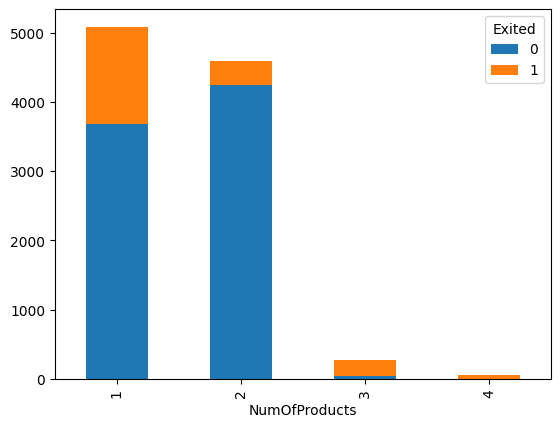

In [21]:
ax = df.groupby(['NumOfProducts', 'Exited']).size().unstack().plot(kind='bar', stacked=True)
ax.figure.savefig("supplementary/figures/numofproducts_churn.png", dpi=150, bbox_inches="tight")


NumOfProducts_Summary = df.groupby('NumOfProducts').agg(
    Count_NumOfProducts = ('NumOfProducts','count'),
    Exited_Customers = ('Exited','sum'),
    Percent_exited = ('Exited',lambda x: x.mean() * 100),
    Male_Percentage = ('Gender', lambda x: (x=='Male').mean()*100),
    Average_age = ('Age','mean')
).reset_index()

print(NumOfProducts_Summary)


From the data, we can see that while a large number of customers (about 1/4) exited with 1 product, as customers received more products (3 and 4), the likelihood of them leaving the bank skyrocketed, with a 100% exit rate when customers had 4 products.

Hypthoesis:
1. Customers with only 1 product could potentially leave as they are trying out the product, and leave regardless if their experience is good or bad
2. Customers with 3 or 4 products almost certainly exited the bank, likely due to mediocre or negative experience with multiple products. This implies an unsatisfactory experience with the products the bank offers

Customers who had 3 or 4 products also appeared to be slightly older, and a larger proportion of them are women (only 44% for 3 products and 36.7% for 4 products are males)

# Investigating Age Variable

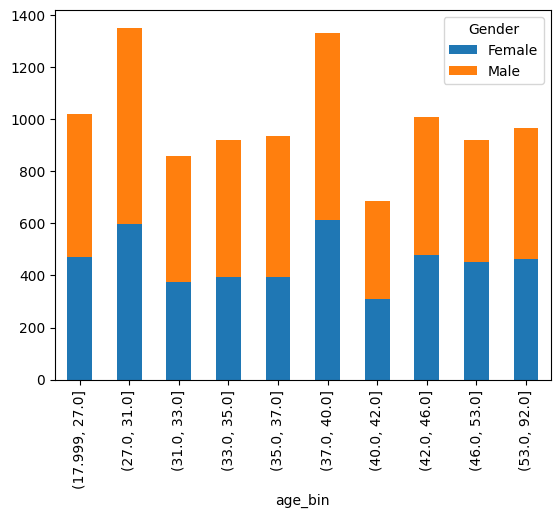

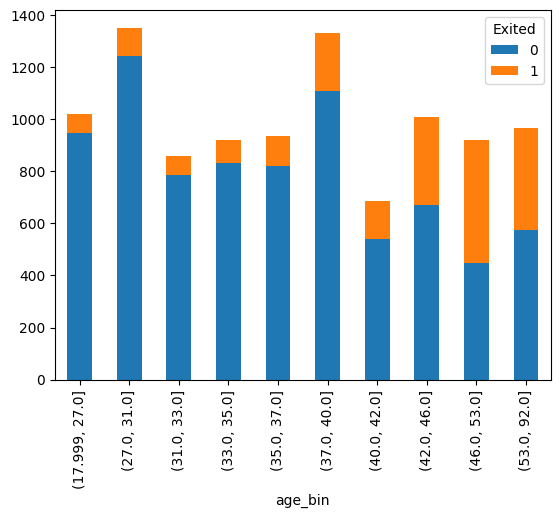

From the data, we can see that the distribution of ages across the customer profiles is quite even.
The % of people above the age of 42 = 28.94%



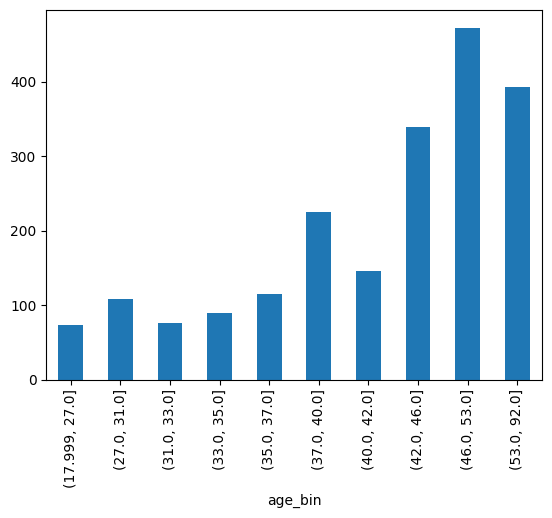

Total exits = 2038
Total exits above the age of 42 = 1205

Total % of exits above the age of 42 = 59.13%


In [22]:
# Separating Age into categorical bins
df['age_bin']=pd.qcut(df['Age'],q=10)

# Plotting a bar chart of the age bins with Gender
ax = df.groupby(['age_bin', 'Gender']).size().unstack().plot(kind='bar', stacked=True)
ax.figure.savefig("supplementary/figures/age_bin_gender.png", dpi=150, bbox_inches="tight")
plt.show()
# Plotting a bar chart of the age bins with the number of customers who stayed and exited
ax = df.groupby(['age_bin', 'Exited']).size().unstack().plot(kind='bar', stacked=True)
ax.figure.savefig("supplementary/figures/age_bin_exited.png", dpi=150, bbox_inches="tight")
plt.show()

# Finding the total % of people who are above the age of 42
percent_of_people_above_42 = (df[df['Age']>42].shape[0]/df.shape[0])*100
print("From the data, we can see that the distribution of ages across the customer profiles is quite even.")
print(f"The % of people above the age of 42 = {percent_of_people_above_42:.2f}%")
print("")

# Plotting the sum of people who exited the bank by age group
ax = df.groupby('age_bin')['Exited'].sum().plot(kind='bar')
ax.figure.savefig("supplementary/figures/age_bin_exit_sum.png", dpi=150, bbox_inches="tight")
plt.show()

total_exits = df['Exited'].sum()
total_exits_above_42 = df[df['Age'] > 42]['Exited'].sum()
percent_of_exits_above_42 = total_exits_above_42/total_exits * 100

print(f"Total exits = {total_exits}")
print(f"Total exits above the age of 42 = {total_exits_above_42}")
print("")
print(f"Total % of exits above the age of 42 = {percent_of_exits_above_42:.2f}%")


From this, we can see that people above the age of 42 are more likely to exit the bank.
From the data, the ages of bank customers are pretty evenly distributed with the % of people above the age of 42 being ~29%.

However, these 29% of customers above the age of 42 account for more than 59% of all exits.



# Geography

In [23]:
df.groupby('Geography').agg(
    Avg_CreditScore=('CreditScore', 'mean'),
    Avg_Age=('Age', 'mean'),
    Avg_Tenure=('Tenure', 'mean'),
    Avg_Balance=('Balance', 'mean'),
    Avg_Products=('NumOfProducts', 'mean'),
    Avg_Salary=('EstimatedSalary', 'mean'),
    Avg_Satisfaction=('Satisfaction Score', 'mean'),
    Avg_Points=('Point Earned', 'mean')
)

,Avg_CreditScore,Avg_Age,Avg_Tenure,Avg_Balance,Avg_Products,Avg_Salary,Avg_Satisfaction,Avg_Points
Geography,,,,,,,,
France,649.6683,38.5118,5.0046,62092.6365,1.5309,99899.1808,3.0178,607.1699
Germany,651.4536,39.7716,5.0100,119730.1161,1.5197,101113.4351,3.0060,610.2152
Spain,651.3339,38.8910,5.0323,61818.1478,1.5394,99440.5723,3.0137,601.4417


The Average Balance for Germany is almost double that of France and Spain, and we have previously noted that this is due to the absence of "0" Balance records for every customer in Germany.

In [24]:
Exits_by_Geography = df.groupby(["Geography"]).agg(
    Geography_Count = ('Geography','count'),
    Exited = ('Exited','sum'),
    Percentage_of_Exits = ('Exited', lambda x: x.mean() *100),
    Genders = ('Gender', lambda x: (x=='Male').mean()*100),
    Average_Age = ("Age", 'mean')
).reset_index()

print(Exits_by_Geography)

  Geography  Geography_Count  Exited  Percentage_of_Exits  Genders  Average_Age
0    France             5014     811              16.1747  54.9063      38.5118
1   Germany             2509     814              32.4432  52.4512      39.7716
2     Spain             2477     413              16.6734  56.0355      38.8910


Customers from Germany have about twice as many percentage point exits as France and Spain.

We should investigate what it is about Germany that is making customers exit. 

In [25]:
Exits_by_Geography = df.groupby(["NumOfProducts","Geography"]).agg(
    Geography_Count = ('Geography','count'),
    Exited = ('Exited','sum'),
    Percentage_of_Exits = ('Exited', lambda x: x.mean() *100),
    Genders = ('Gender', lambda x: (x=='Male').mean()*100),
    Age = ('Age','mean')
).reset_index()

print(Exits_by_Geography)

    NumOfProducts Geography  Geography_Count  Exited  Percentage_of_Exits  Genders     Age
0               1    France             2514     564              22.4344  55.6086 39.1754
1               1   Germany             1349     578              42.8466  50.7784 40.5723
2               1     Spain             1221     267              21.8673  57.7396 39.7043
3               2    France             2367     136               5.7457  54.7529 37.4537
4               2   Germany             1040     126              12.1154  55.5769 38.2673
5               2     Spain             1183      87               7.3542  55.4522 37.9019
6               3    France              104      82              78.8462  47.1154 44.2212
7               3   Germany               96      86              89.5833  44.7917 43.6562
8               3     Spain               66      52              78.7879  37.8788 40.9091
9               4    France               29      29             100.0000  34.4828 46.8621

For all 4 countries, having 4 products almost guarantees an exit. for customers with only 1 product, Germany has almost double the churn rate than the other 2 countries.

# Is Active Member

In [26]:
df.groupby(['Geography','Gender','IsActiveMember']).agg(
    Count = ('Geography','count'),
    Exited = ('Exited','sum'),
    Churn_Rate = ('Exited', lambda x: x.mean() *100) 
)

Count  Exited  Churn_Rate
Geography Gender IsActiveMember                           
France    Female 0                1099     288     26.2056
                 1                1162     172     14.8021
          Male   0                1324     225     16.9940
                 1                1429     126      8.8174
Germany   Female 0                 634     283     44.6372
                 1                 559     165     29.5170
          Male   0                 627     235     37.4801
                 1                 689     131     19.0131
Spain     Female 0                 526     154     29.2776
                 1                 563      77     13.6767
          Male   0                 639     118     18.4664
                 1                 749      64      8.5447

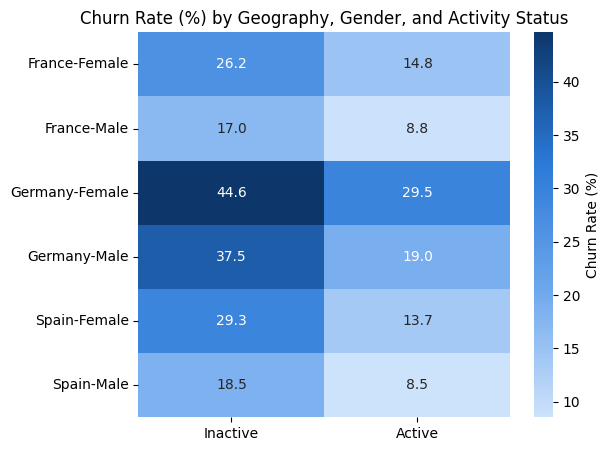

In [27]:
geo_gender_active = df.groupby(['Geography', 'Gender', 'IsActiveMember']).agg(
    Count=('Geography', 'count'),
    Exited=('Exited', 'sum'),
    Churn_Rate=('Exited', lambda x: x.mean() * 100)
)

churn_grid = geo_gender_active['Churn_Rate'].unstack('IsActiveMember')
churn_grid.columns = ['Inactive', 'Active']

from matplotlib.colors import LinearSegmentedColormap
blue_seq = LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(churn_grid, annot=True, fmt=".1f", cmap=blue_seq,
            cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Geography, Gender, and Activity Status')
plt.ylabel('')
plt.savefig("supplementary/figures/active_member_churn_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


1. There is quite a consistent ratio of Active and Inactive members across the board Genders and Geography

2. There is already a higher baseline Churn Rate for women (25%) vs men (16%)

3. An inactive member resulted in an almost 100% increase in Churn Rate across all Genders and Geography



Being an inactive member results in an almost 100% increase in the churn rate across all countries

# Credit Score

In [28]:
# Separating credit score into categorical bins
bins = [350,425,550,675,800,925]
labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

df['Credit Score Band'] = pd.cut(df['CreditScore'],bins=bins, labels=labels,right=False)

In [29]:
pd.crosstab(df["Credit Score Band"], df["Exited"])

Exited,0,1
Credit Score Band,,
Very Low,34,32
Low,1195,329
Moderate,3405,874
High,2801,675
Very High,527,128


In [30]:
df.groupby(['Credit Score Band','Geography']).agg(
    Avg_Age=('Age', 'mean'),
    Avg_Tenure=('Tenure', 'mean'),
    Avg_Balance=('Balance', 'mean'),
    Avg_Products=('NumOfProducts', 'mean'),
    Avg_Salary=('EstimatedSalary', 'mean'),
    Avg_Satisfaction=('Satisfaction Score', 'mean'),
    Avg_Points=('Point Earned', 'mean')
    )

Avg_Age  Avg_Tenure  Avg_Balance  Avg_Products  Avg_Salary  Avg_Satisfaction  Avg_Points
Credit Score Band Geography                                                                                          
Very Low          France     40.2727      5.6970   49906.8200        1.3939  92826.2958            2.6364    652.3939
                  Germany    38.5000      3.4375  122233.6406        1.7500 108739.4675            2.9375    522.8750
                  Spain      43.3529      4.2353   72655.6676        1.4118  96725.9729            3.2353    648.1765
Low               France     38.1864      4.9118   61503.6977        1.5038 101345.9840            3.0567    600.4118
                  Germany    40.7183      5.2791  121270.3961        1.5090 101613.9069            3.0052    629.2481
                  Spain      38.7259      5.0758   59628.4556        1.5248  97483.7848            3.0292    591.3790
Moderate          France     38.7421      5.0659   61114.5759        1.5401  98365.1776            3.0408    607.4889
                  Germany    39.6013      5.0046  119725.5197        1.5130 101064.5730            3.0084    611.2119
                  Spain      38.6801      4.9589   63832.1457        1.5356 101009.7352            3.0174    599.0411
High              France     38.3886      4.9521   63280.8045        1.5316 100688.5052            2.9915    606.1185
                  Germany    39.6593      4.9824  119711.1504        1.5258 101149.5056            3.0176    602.3782
                  Spain      38.9262      5.1142   60605.0690        1.5433  98858.7766            3.0254    609.3979
Very High         France     38.2972      5.0464   64715.6841        1.5480 102792.6541            2.9536    622.7926
                  Germany    39.3920      4.7273  116235.7848        1.5341  99443.3914            2.9432    608.2386
                  Spain      40.0513      5.0833   58069.7636        1.5897  96268.0015            2.8654    591.0897

<Axes: xlabel='Credit Score Band'>

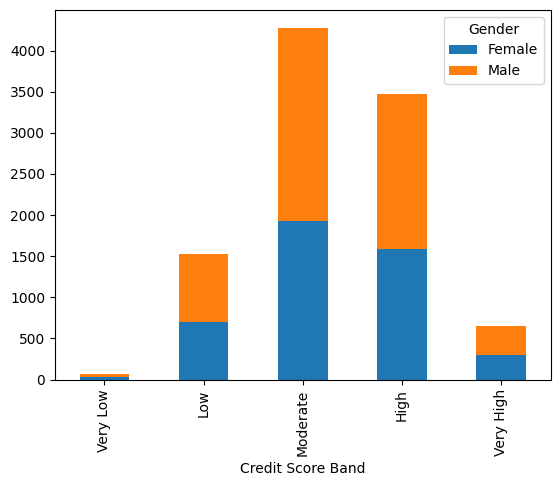

In [31]:
df.groupby(['Credit Score Band', 'Gender']).size().unstack().plot(kind='bar', stacked=True)


Even split of genders across all credit score bands

In [32]:
Credit_Score_Band_Summary = df.groupby(['Credit Score Band','Geography']).agg(
    Credit_Score_Band_Count = ('Credit Score Band','count'),
    Percent_of_exits = ('Exited',lambda x: x.mean() * 100)
).reset_index()

print(Credit_Score_Band_Summary)

   Credit Score Band Geography  Credit_Score_Band_Count  Percent_of_exits
0           Very Low    France                       33           39.3939
1           Very Low   Germany                       16           62.5000
2           Very Low     Spain                       17           52.9412
3                Low    France                      794           17.8841
4                Low   Germany                      387           33.8501
5                Low     Spain                      343           16.3265
6           Moderate    France                     2109           16.1214
7           Moderate   Germany                     1076           32.3420
8           Moderate     Spain                     1094           17.0018
9               High    France                     1755           15.1567
10              High   Germany                      854           31.9672
11              High     Spain                      867           15.6863
12         Very High    France        

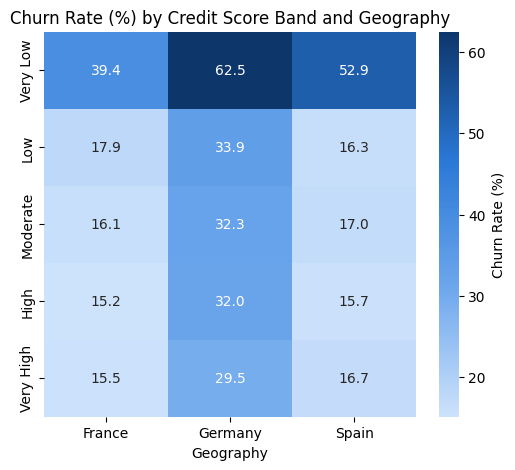

In [33]:
credit_geo_grid = Credit_Score_Band_Summary.pivot(
    index='Credit Score Band', columns='Geography', values='Percent_of_exits'
)

plt.figure(figsize=(6, 5))
sns.heatmap(credit_geo_grid, annot=True, fmt=".1f", cmap=blue_seq,
            cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Credit Score Band and Geography')
plt.ylabel('')
plt.savefig("supplementary/figures/credit_score_churn_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


Customers with a very low credit score have a much higher churn rate than customers with a credit score of low to very high

# Credit Card

In [34]:
df.groupby(["Card Type"]).agg(
    Avg_Age=('Age', 'mean'),
    Avg_Tenure=('Tenure', 'mean'),
    Avg_Balance=('Balance', 'mean'),
    Avg_Products=('NumOfProducts', 'mean'),
    Avg_Salary=('EstimatedSalary', 'mean'),
    Avg_Satisfaction=('Satisfaction Score', 'mean'),
    Avg_Points=('Point Earned', 'mean'),
    Exited = ('Exited','sum'),
    Percentage_of_Exits = ('Exited', lambda x: x.mean() *100),
    Genders = ('Gender', lambda x: (x=='Male').mean()*100)
)

,Avg_Age,Avg_Tenure,Avg_Balance,Avg_Products,Avg_Salary,Avg_Satisfaction,Avg_Points,Exited,Percentage_of_Exits,Genders
Card Type,,,,,,,,,,
DIAMOND,38.9912,5.0092,79120.0172,1.5114,98525.7634,2.9936,605.9836,546,21.7790,53.6099
GOLD,38.9384,5.0743,76695.3620,1.5216,100550.9595,3.0444,607.2358,482,19.2646,57.5540
PLATINUM,39.0080,4.9186,75692.7076,1.5511,100197.5448,3.0100,608.8397,508,20.3607,53.4269
SILVER,38.7492,5.0489,74423.0403,1.5369,101092.5221,3.0072,604.0028,502,20.1122,53.6859


Card Type churn rates range from 19.3% (Gold) to 21.8% (Diamond), a ~2.5 percentage point spread against a 20.4% base rate (noise rather than a signal). It matches the revised regression, where none of the three Card Type dummies were statistically significant (p = 0.20 to 0.83). 

Correctly ruled out, no further investigation needed here.

In [35]:
df.groupby(['HasCrCard','Geography']).agg(
Avg_Age=('Age', 'mean'),
Avg_Tenure=('Tenure', 'mean'),
Avg_Balance=('Balance', 'mean'),
Avg_Products=('NumOfProducts', 'mean'),
Avg_Salary=('EstimatedSalary', 'mean'),
Avg_Satisfaction=('Satisfaction Score', 'mean'),
Geography_Count = ('Geography','count'),
Exited = ('Exited','sum'),
Percentage_of_Exits = ('Exited', lambda x: x.mean() *100),
Genders = ('Gender', lambda x: (x=='Male').mean()*100)
)

Avg_Age  Avg_Tenure  Avg_Balance  Avg_Products  Avg_Salary  Avg_Satisfaction  Geography_Count  Exited  Percentage_of_Exits  Genders
HasCrCard Geography                                                                                                                                     
0         France     38.6404      4.9205   64554.5846        1.5391 100967.7956            3.0197             1471     241              16.3834  53.5690
          Germany    40.1407      4.8454  118211.5474        1.4972  99872.4871            3.0028              718     237              33.0084  51.2535
          Spain      39.0529      4.9577   65662.7439        1.5331 102033.7674            3.0146              756     135              17.8571  57.9365
1         France     38.4584      5.0395   61070.4729        1.5275  99455.5081            3.0169             3543     570              16.0881  55.4615
          Germany    39.6237      5.0759  120338.9002        1.5288 101610.9229            3.0073             1791     577              32.2166  52.9313
          Spain      38.8199      5.0651   60129.2955        1.5421  98301.4349            3.0134             1721     278              16.1534  55.2005

Having a credit card or not does not seem to have an impact on the churn rate.

# Balance

In [36]:
count_of_zero = (df['Balance'] == 0).sum()
print(f"There are {count_of_zero} out of 10000 accounts with zero balance")

There are 3617 out of 10000 accounts with zero balance


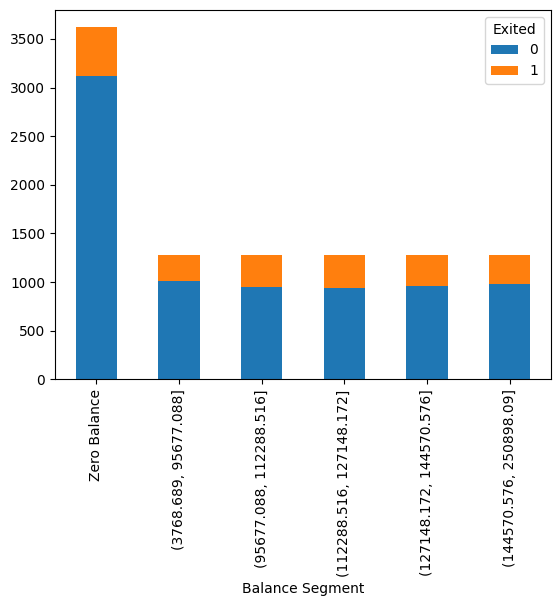

In [37]:
# Separate customers with exactly $0 balance (36% of the base) from everyone
# else before binning. Quantile-cutting the whole column treats that $0 mass
# point as just the bottom of a continuum, which buries the more interesting
# zero-vs-positive split and forces duplicates='drop' to even run.
df['Balance Segment'] = 'Zero Balance'
positive_mask = df['Balance'] > 0
df.loc[positive_mask, 'Balance Segment'] = pd.qcut(df.loc[positive_mask, 'Balance'], q=5).astype(str)

# order Zero Balance first, then the quintiles ascending by their lower bound
# (plain string groupby would sort alphabetically and scatter these)
quintile_labels = sorted(
    df.loc[positive_mask, 'Balance Segment'].unique(),
    key=lambda s: float(s.split(',')[0][1:])
)
segment_order = ['Zero Balance'] + quintile_labels
df['Balance Segment'] = pd.Categorical(df['Balance Segment'], categories=segment_order, ordered=True)

df.groupby(['Balance Segment', 'Exited'], observed=True).size().unstack().plot(kind='bar', stacked=True)
plt.show()

In [38]:
Balance_Segment_Summary = df.groupby('Balance Segment', observed=True).agg(
    Count = ('Balance Segment','count'),
    Exited_Customers = ('Exited','sum'),
    Percent_exited = ('Exited', lambda x: x.mean() * 100)
).reset_index()

print(Balance_Segment_Summary)

            Balance Segment  Count  Exited_Customers  Percent_exited
0              Zero Balance   3617               500         13.8236
1     (3768.689, 95677.088]   1277               266         20.8301
2   (95677.088, 112288.516]   1276               321         25.1567
3  (112288.516, 127148.172]   1277               342         26.7815
4  (127148.172, 144570.576]   1276               316         24.7649
5   (144570.576, 250898.09]   1277               293         22.9444


In [39]:
# Cross-country comparison needs a coarser split than the 5 pooled quintiles.
# Positive balances turn out to be almost identical across countries (~119.7k-119.9k
# average each — checked separately), so the quintile boundaries aren't distorted by
# country, but slicing into 5 bins x 3 countries mostly just adds small-sample noise.
# The zero-vs-positive split is what actually differs by country (Germany has 0
# zero-balance customers vs ~48% in France/Spain), so that's the comparison to make.
df['Has Balance'] = np.where(df['Balance'] == 0, 'Zero Balance', 'Positive Balance')

Balance_by_Geography = df.groupby(['Geography', 'Has Balance']).agg(
    Count = ('Has Balance','count'),
    Exited_Customers = ('Exited','sum'),
    Percent_exited = ('Exited', lambda x: x.mean() * 100)
).reset_index()

print(Balance_by_Geography)

  Geography       Has Balance  Count  Exited_Customers  Percent_exited
0    France  Positive Balance   2596               474         18.2589
1    France      Zero Balance   2418               337         13.9371
2   Germany  Positive Balance   2509               814         32.4432
3     Spain  Positive Balance   1278               250         19.5618
4     Spain      Zero Balance   1199               163         13.5947


The split reveals something the continuous view hid: **zero-balance customers churn at 13.8%, versus 20.8%–26.8% across every positive-balance quintile.** That's a ~10-point gap, and it isn't explained by the amount of money in the account — within the positive-balance group, churn only drifts between 20.8% and 26.8% with no clear trend as balance rises, consistent with the revised regression finding continuous `Balance` not significant (p = 0.25).

This fully explains the earlier observation that Germany's average balance looks almost double France/Spain's: **100% of German customers have a positive balance, versus only ~48% in France and ~52% in Spain having a positive balance (the rest are $0).** Among customers who *do* have a balance, the average is nearly identical across all three countries (France 119,928, Germany 119,730, Spain 119,815). Germany's higher overall average isn't because German customers hold more money, but more so from having no $0-balance accounts to drag its average down.

The zero-vs-positive gap also holds within each country individually (see the table above): France is 13.9% (zero) vs. 18.3% (positive), Spain is 13.6% (zero) vs. 19.6% (positive), which is smaller than the pooled 13.8%/~24% gap (partly inflated by Germany being both all-positive-balance *and* a high-churn country), but real and consistent in both countries that have a zero-balance segment to compare against.

Hypothesis: A $0 balance marks a different kind of account (e.g. never funded, or used purely for a secondary product) rather than a financially disengaged customer who's about to leave. Ironically if anything, the disengaged group churns less here, which contradicts the "lower balance → more likely to leave" hypothesis in the Field Descriptions section. 

# Combined factors

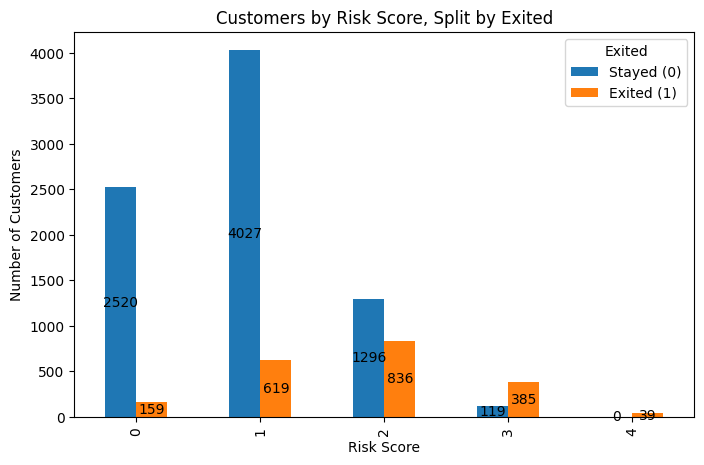

In [40]:
# Combine the 4 factors that came out independently significant in the revised
# regression (Geography=Germany, IsActiveMember=0, Age>42, NumOfProducts>=3) into
# a single 0-4 Risk Score per customer, to check whether these effects compound.
df['Risk_Germany'] = (df['Geography'] == 'Germany').astype(int)
df['Risk_Inactive'] = (df['IsActiveMember'] == 0).astype(int)
df['Risk_Age_Over_42'] = (df['Age'] > 42).astype(int)
df['Risk_MultiProduct'] = (df['NumOfProducts'] >= 3).astype(int)

df['Risk_Score'] = (df['Risk_Germany'] + df['Risk_Inactive'] +
                     df['Risk_Age_Over_42'] + df['Risk_MultiProduct'])

risk_exit_counts = df.groupby(['Risk_Score', 'Exited']).size().unstack()

ax = risk_exit_counts.plot(kind='bar', stacked=False, figsize=(8, 5))
for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.title('Customers by Risk Score, Split by Exited')
plt.xlabel('Risk Score')
plt.ylabel('Number of Customers')
plt.legend(title='Exited', labels=['Stayed (0)', 'Exited (1)'])
plt.savefig("supplementary/figures/risk_score_churn.png", dpi=150, bbox_inches="tight")
plt.show()


In [41]:
Risk_Score_Summary = df.groupby('Risk_Score').agg(
    Count = ('Risk_Score', 'count'),
    Exited_Customers = ('Exited', 'sum'),
    Churn_Rate = ('Exited', lambda x: x.mean() * 100)
).reset_index()

print(Risk_Score_Summary)

   Risk_Score  Count  Exited_Customers  Churn_Rate
0           0   2679               159      5.9351
1           1   4646               619     13.3233
2           2   2132               836     39.2120
3           3    504               385     76.3889
4           4     39                39    100.0000


Stacking the four factors produces a clean, almost monotonic staircase:

| Risk Score | Count | % of customers | Churn rate |
|---|---|---|---|
| 0 (none present) | 2,679 | 26.8% | 5.9% |
| 1 | 4,646 | 46.5% | 13.3% |
| 2 | 2,132 | 21.3% | 39.2% |
| 3 | 504 | 5.0% | 76.4% |
| 4 (all present) | 39 | 0.4% | 100.0% |

Overall base rate is 20.4%. Customers with 0 risk factors churn at less than a third of the base rate (5.9%); customers with a Risk Score of 3 or higher (543 customers combined, 5.4% of the base) churn at 78.1%, a segment small enough to be actionable and large enough to matter, and roughly 4x the base rate. Risk Score 4 alone (39 customers, 100% churn) is a small but valid group to flag.

# Variables I investigated but had minimal/no impact on churn:
1. Tenure

<Axes: xlabel='Tenure'>

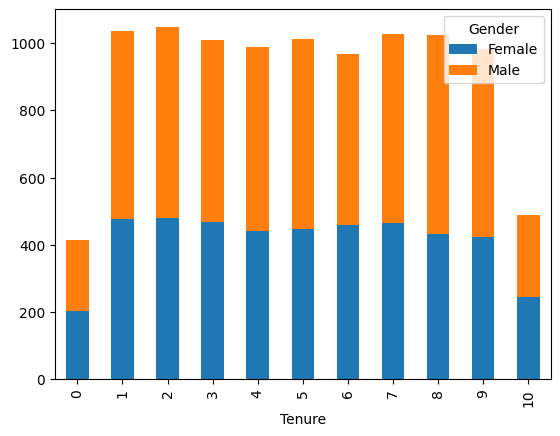

In [42]:
df.groupby(['Tenure', 'Gender']).size().unstack().plot(kind='bar', stacked=True)

# Key Findings from my investigation and analysis

The data is mostly clean (no missing values, no duplicate customers), with one notable quirk: 36% of accounts have exactly $0 balance with every single one of them being in France or Spain while Germany has none.

A revised logistic regression (after removing `Complain`, which was leaking the outcome and causing quasi-separation) points to six real drivers of churn, all significant at p < 0.05:

- **NumOfProducts** - by far the strongest driver. Churn is ~8% for 2 products but 100% for 4; 3+ products is a clear high risk segment.
- **Age** - each extra year raises churn odds ~7.4%; customers over 42 are 29% of the base but 59% of exits.
- **Geography (Germany)** - Germany churns at ~2x the rate of France/Spain (32.4% vs ~16%), independent of Germany's higher average balance.
- **IsActiveMember** - inactive members churn at roughly double the rate of active members, consistently across every country and gender.
- **Gender** - women churn at 25.1% vs 16.5% for men.
- **CreditScore** - statistically significant but small in practice; only the "Very Low" band (350-425) stands out with a materially higher churn rate.

Stacking the four strongest, independent drivers (Germany, inactive, age over 42, 3+ products) into a single 0 to 4 Risk Score produces a near-monotonic staircase: customers with 0 factors churn at 5.9%, customers with all 4 churn at 100%.

**Full write-up** including all supporting tables, regression output, VIF diagnostics, and every chart can be viewed at [README.md](README.md).